In [1]:
import cvxpy as cp
from itertools import permutations
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")

In [2]:
n_user = 3
h_bad =  0.1
h_good = 1
pr_h_bad = 0.5
pr_h_good = (1- pr_h_bad)
r_max = 2
rho = np.arange(0, r_max+1, 1)
print('rho', rho)

rho [0 1 2]


In [3]:
h_vec_u1 = np.array([h_bad,  h_good]).tolist()
permutations_list = []
permutations_list.extend(list(product(h_vec_u1, repeat=n_user )))
combined_h_vec = []
for permutation in permutations_list:
    arr = []
    for k in permutation:
        arr.append(k)
    combined_h_vec.append(arr)
p_h_u1 = np.array([pr_h_bad, pr_h_good])
permutations_list = []
permutations_list.extend(list(product(p_h_u1, repeat=n_user )))
pr_h = []
for permutation in permutations_list:
    arr = []
    for k in permutation:
        arr.append(k)
    pr_h.append(np.prod(arr))
hp = pr_h
h = combined_h_vec
print('h:', h)
print('prob h:', hp)

h: [[0.1, 0.1, 0.1], [0.1, 0.1, 1.0], [0.1, 1.0, 0.1], [0.1, 1.0, 1.0], [1.0, 0.1, 0.1], [1.0, 0.1, 1.0], [1.0, 1.0, 0.1], [1.0, 1.0, 1.0]]
prob h: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]


In [4]:
W = list(product(rho, repeat=n_user))
# W = [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (0, 2, 0), (0, 0, 1), (0, 0, 2) ]
rho_DO = []
poss_dec_ord = [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]
# poss_dec_ord = [(1, 2), (2, 1)]
for w in W:
    for DO in poss_dec_ord:
        rho_DO.append([w, DO])
print('rho, DO:', rho_DO)

rho, DO: [[(0, 0, 0), (1, 2, 3)], [(0, 0, 0), (1, 3, 2)], [(0, 0, 0), (2, 1, 3)], [(0, 0, 0), (2, 3, 1)], [(0, 0, 0), (3, 1, 2)], [(0, 0, 0), (3, 2, 1)], [(0, 0, 1), (1, 2, 3)], [(0, 0, 1), (1, 3, 2)], [(0, 0, 1), (2, 1, 3)], [(0, 0, 1), (2, 3, 1)], [(0, 0, 1), (3, 1, 2)], [(0, 0, 1), (3, 2, 1)], [(0, 0, 2), (1, 2, 3)], [(0, 0, 2), (1, 3, 2)], [(0, 0, 2), (2, 1, 3)], [(0, 0, 2), (2, 3, 1)], [(0, 0, 2), (3, 1, 2)], [(0, 0, 2), (3, 2, 1)], [(0, 1, 0), (1, 2, 3)], [(0, 1, 0), (1, 3, 2)], [(0, 1, 0), (2, 1, 3)], [(0, 1, 0), (2, 3, 1)], [(0, 1, 0), (3, 1, 2)], [(0, 1, 0), (3, 2, 1)], [(0, 1, 1), (1, 2, 3)], [(0, 1, 1), (1, 3, 2)], [(0, 1, 1), (2, 1, 3)], [(0, 1, 1), (2, 3, 1)], [(0, 1, 1), (3, 1, 2)], [(0, 1, 1), (3, 2, 1)], [(0, 1, 2), (1, 2, 3)], [(0, 1, 2), (1, 3, 2)], [(0, 1, 2), (2, 1, 3)], [(0, 1, 2), (2, 3, 1)], [(0, 1, 2), (3, 1, 2)], [(0, 1, 2), (3, 2, 1)], [(0, 2, 0), (1, 2, 3)], [(0, 2, 0), (1, 3, 2)], [(0, 2, 0), (2, 1, 3)], [(0, 2, 0), (2, 3, 1)], [(0, 2, 0), (3, 1, 2)], [(0, 2

In [6]:
def cal_pow(R, DO, h_val):
    sorted_list = DO
    pow_vals = np.zeros(len(DO))
    for i in range(len(DO)):
        idx = DO[i]-1
        sum_i_M = np.sum([R[DO[k]-1]  for k in range(i, len(DO))])
        sum_ip1_M = np.sum([R[DO[k]-1] for k in range(min(i+1, len(DO)), len(DO))])
        pow = (2**(sum_i_M) - 2**(sum_ip1_M))/h_val[idx]
        pow_vals[idx] = pow
    return pow_vals

# for h_vals2 in h:
#     for item in rho_DO:
#         res = cal_pow(item[0], item[1] , h_vals2)
#         print(h_vals2, item, res)
#     print('------------------------')


In [7]:
def SRP(P_bar, D_bar, l, scheme):
    r_max = 2
    n_user = 3
    pkt_prob = n_user*[l]
    weights = n_user*[1/n_user]
    P_bar_U = n_user*[P_bar]
    D_bar_U = n_user*[D_bar]
    mu = cp.Variable((len(h), len(rho_DO) ), pos = True)
    p = []
    for x in range(n_user):
        temp  = 0
        for k in range(len(h)):
            for j in range(len(rho_DO)):
                if rho_DO[j][0][x] != 0:
                    temp+= mu[k][j] * hp[k]
        p.append(temp)
    P_u = []
    for x in range(n_user):
        temp = 0
        for k in range(len(h)):
            for j in range( len(rho_DO)):
                temp+= cal_pow(rho_DO[j][0], rho_DO[j][1] , h[k])[x] * mu[k][j] *  hp[k]
        P_u.append(temp)
    D_u = []
    for x in range(n_user):
        temp = 0
        for k in range(len(h)):
            for j in range( len(rho_DO)):
                bit = rho_DO[j][0][x]
                # temp+= (np.exp(-bit) * mu[k][j] *  hp[k] * int(bit > 0))
                temp+= ((1 - bit/r_max)**(2) * mu[k][j] *  hp[k] * int(bit > 0))
        D_u.append(temp)
    obj_fun = 0
    for n in range(n_user):
        obj_fun = obj_fun + ( weights[n] *  pkt_prob[n] * (cp.inv_pos(p[n])  -  1 )  )
    objective = cp.Minimize(obj_fun)
    constraints = []
    for n in range(n_user):
        val1 = pkt_prob[n] * (1- p[n])+ p[n]
        constraints.append(D_u[n]*pkt_prob[n] <= D_bar_U[n] * val1)
    if scheme == 'w/ PA':
        for n in range(n_user):
            val1 = pkt_prob[n] * (1- p[n])+ p[n]
            constraints.append(P_u[n]*pkt_prob[n] <= P_bar_U[n]*val1 )
    else:
        for n in range(n_user):
            constraints.append(P_u[n] <= P_bar_U[n] )
    a_val = []
    for q in range(len(h)):
        a_val.append( cp.sum([ mu[q][j] for j in range(len(rho_DO))]))
    for a in a_val:
        constraints.append(a == 1)
    for i in range(len(h)):           
        for j in range(len(rho_DO)):
            constraints.append(0<= mu[i][j])
            constraints.append(mu[i][j] <= 1)
    prob = cp.Problem(objective, constraints)
    prob.solve()
    ########################################3
    final_mus =[]
    for j in range(len(h)):
        h_mu_vals = []
        for k in range(len(W)):
            h_mu_vals.append(np.round(np.sum(mu[j].value[k*6:(k+1)*6]), 3))
        final_mus.append(h_mu_vals)
    # for z in range(len(h)):
    #     print(final_mus[j], np.sum(final_mus[j]))
    return prob.value, final_mus

## SRP runtime

In [8]:
opt_age, mu_vals = SRP(2, 1, 0.5, 'w/ PA')
print('opt age', opt_age)
print('mu', mu_vals)

opt age 0.18041237121396653
mu [[0.0, 0.333, 0.0, 0.333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.455, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.545, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.455, 0.0, 0.0, 0.545, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.455, 0.545, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [9]:


import numpy as np
def fix_sum_to_one(p):
    p = np.array(p, dtype=float)
    diff = 1.0 - p.sum()          # the tiny rounding difference
    idx = np.argmax(p)            # index of largest probability
    p[idx] += diff                # add the difference safely
    return p

    
age = np.array([0, 0, 0])
sum_age = np.array([0, 0, 0])
pkt_prob = 0.5
sum_time = 0
for t in range(1, 100001):
    pkts =np.random.choice([1, 0], size=3, p=[pkt_prob, (1-pkt_prob)])
    h_val_test = np.random.choice([1, 0.1], size=3, p=[0.5, 0.5])

    t_start = time.time()

    idx = np.where((h == h_val_test).all(axis=1))[0]
    age += pkts
    q_state = np.where(age > 0, 1, 0)
    rho_idx = np.random.choice(np.arange(len(W)), size=1, p=fix_sum_to_one(mu_vals[idx[0]]))
    best_bits = np.array(W[rho_idx[0]])
    age = age * np.where(best_bits > 0, 0, 1)
    sum_age+= age
    
    sum_time+= (time.time() - t_start)
    if t%10000 == 0:
            print('lamdbda', pkt_prob, 't', t, 'Avg age:', np.round(np.mean(sum_age)/t, 4))
            print('compute time', sum_time/t )


lamdbda 0.5 t 10000 Avg age: 0.1802
compute time 2.372751235961914e-05
lamdbda 0.5 t 20000 Avg age: 0.1813
compute time 2.383432388305664e-05
lamdbda 0.5 t 30000 Avg age: 0.1822
compute time 2.355810006459554e-05
lamdbda 0.5 t 40000 Avg age: 0.181
compute time 2.347050905227661e-05
lamdbda 0.5 t 50000 Avg age: 0.1805
compute time 2.338972568511963e-05
lamdbda 0.5 t 60000 Avg age: 0.1802
compute time 2.3304263750712076e-05
lamdbda 0.5 t 70000 Avg age: 0.1796
compute time 2.327472141810826e-05
lamdbda 0.5 t 80000 Avg age: 0.1795
compute time 2.3286283016204832e-05
lamdbda 0.5 t 90000 Avg age: 0.1801
compute time 2.3288623491923016e-05
lamdbda 0.5 t 100000 Avg age: 0.1807
compute time 2.32800030708313e-05


In [11]:
import numpy as np
import time
from itertools import product

# M = 3                   # number of users
for M in range(1, 11, 1):
    print('M', M)
    T = 100001                # simulation time
    pkt_prob = 0.5            # packet arrival probability
    channel_levels = [1.0, 0.1]
    h = np.array(list(product(channel_levels, repeat=M)))
    n_states = len(h)         # = 2^M
    # W = np.array(list(product([0, 1, 2], repeat=M)))
    ####################################
    W = [np.zeros(M, dtype=int)]
    for i in range(M):
        vec = np.zeros(M, dtype=int)
        vec[i] = 1
        W.append(vec)
    for i in range(M):
        vec = np.zeros(M, dtype=int)
        vec[i] = 2
        W.append(vec)
    W = np.array(W)
    n_actions = len(W)        # = 2^M
    mu_vals = np.random.rand(n_states, n_actions)
    mu_vals = mu_vals / mu_vals.sum(axis=1, keepdims=True)

    h_dict = {tuple(h[i]): i for i in range(n_states)}
    age = np.zeros(M, dtype=np.int64)
    sum_age = np.zeros(M, dtype=np.int64)
    sum_time = 0

    for t in range(1, T + 1):
        pkts = np.random.choice( [1, 0],  size=M,   p=[pkt_prob, 1 - pkt_prob]  )
        h_val_test = np.random.choice( [1.0, 0.1], size=M, p=[0.5, 0.5] )
        t_start = time.time()
        idx = h_dict[tuple(h_val_test)]
        age += pkts
        rho_idx = np.random.choice( n_actions,  p=mu_vals[idx] )
        best_bits = W[rho_idx]
        age = age * (best_bits == 0)
        sum_age += age
        sum_time += (time.time() - t_start)
        if t % 100000 == 0:
            avg_age_per_user = sum_age / t
            print(
                f"M={M}, t={t}, "
                # f"Avg age per user = {np.round(avg_age_per_user, 4)}, "
                f"Network Avg = {np.round(np.mean(avg_age_per_user), 4)}"
            )

            print(
                "Average compute time per slot:",
                sum_time / t
            )

M 1
M=1, t=100000, Network Avg = 0.2082
Average compute time per slot: 1.1333439350128174e-05
M 2
M=2, t=100000, Network Avg = 0.8299
Average compute time per slot: 1.0347230434417725e-05
M 3
M=3, t=100000, Network Avg = 1.2611
Average compute time per slot: 1.0163378715515137e-05
M 4
M=4, t=100000, Network Avg = 1.7641
Average compute time per slot: 1.0159239768981933e-05
M 5
M=5, t=100000, Network Avg = 2.2612
Average compute time per slot: 1.0177352428436279e-05
M 6
M=6, t=100000, Network Avg = 2.7733
Average compute time per slot: 1.0281598567962647e-05
M 7
M=7, t=100000, Network Avg = 3.2239
Average compute time per slot: 1.0280575752258301e-05
M 8
M=8, t=100000, Network Avg = 3.7597
Average compute time per slot: 1.0331354141235351e-05
M 9
M=9, t=100000, Network Avg = 4.2496
Average compute time per slot: 1.0438566207885742e-05
M 10
M=10, t=100000, Network Avg = 4.7688
Average compute time per slot: 1.0538873672485352e-05


In [ ]:
0.001511, 

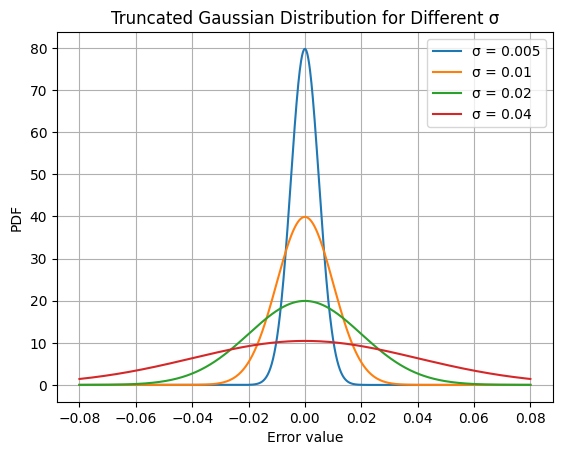

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

def trunc_error(sigma, low, high, size):
    a = low / sigma
    b = high / sigma
    return truncnorm.rvs(a, b, loc=0, scale=sigma, size=size)

low = -0.08
high = 0.08

sigmas = [0.005, 0.01, 0.02, 0.04]

x = np.linspace(low, high, 1000)

for sigma in sigmas:
    a = low / sigma
    b = high / sigma
    
    pdf = truncnorm.pdf(x, a, b, loc=0, scale=sigma)
    
    plt.plot(x, pdf, label=f'σ = {sigma}')

plt.xlabel('Error value')
plt.ylabel('PDF')
plt.title('Truncated Gaussian Distribution for Different σ')
plt.legend()
plt.grid(True)

plt.show()

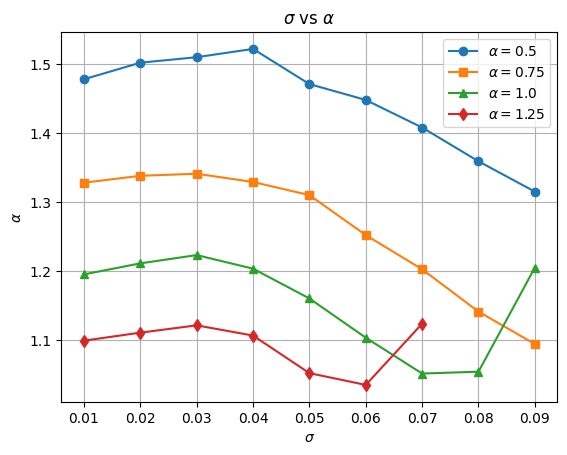

In [3]:
import matplotlib.pyplot as plt
import numpy as np

sigma = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

alpha_1 = [1.478, 1.502, 1.51, 1.522, 1.471, 1.448, 1.408, 1.359, 1.315]
alpha_2 = [1.328, 1.338, 1.341, 1.329, 1.31, 1.252, 1.2024, 1.141, 1.094]
alpha_3 = [1.195, 1.211, 1.223, 1.2033, 1.1601, 1.1032, 1.0512, 1.0539, 1.2049]
alpha_4 = [1.0989, 1.1105, 1.1211, 1.1063, 1.0518, 1.0347, 1.1235, np.nan, np.nan]

plt.plot(sigma, alpha_1, marker='o', label=r'$\alpha = 0.5$')
plt.plot(sigma, alpha_2, marker='s', label=r'$\alpha = 0.75$')
plt.plot(sigma, alpha_3, marker='^', label=r'$\alpha = 1.0$')
plt.plot(sigma, alpha_4, marker='d', label=r'$\alpha = 1.25$')

plt.xlabel(r'$\sigma$')
plt.ylabel(r'$\alpha$')
plt.title(r'$\sigma$ vs $\alpha$')
plt.grid(True)
plt.legend()

plt.show()

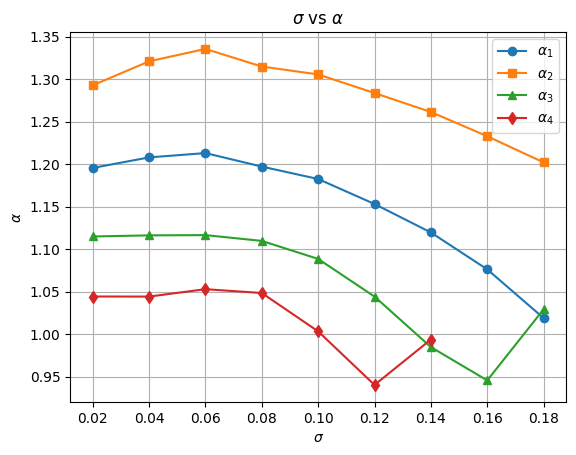

In [9]:
import matplotlib.pyplot as plt
import numpy as np

sigma = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]

alpha_1 = [1.1955, 1.2079, 1.213, 1.1971, 1.1825, 1.1531, 1.1196, 1.0762, 1.0189]

alpha_2 = [1.2927, 1.3209, 1.3355, 1.3148, 1.3055, 1.2836, 1.2613, 1.2328, 1.202]

alpha_3 = [1.1149, 1.1162, 1.1165, 1.1097, 1.0885, 1.0442, 0.9848, 0.9456, 1.0293]

alpha_4 = [1.0443, 1.0442, 1.0529, 1.0484, 1.0033, 0.9403, 0.9937, np.nan, np.nan]

plt.plot(sigma, alpha_1, marker='o', label=r'$\alpha_1$')
plt.plot(sigma, alpha_2, marker='s', label=r'$\alpha_2$')
plt.plot(sigma, alpha_3, marker='^', label=r'$\alpha_3$')
plt.plot(sigma, alpha_4, marker='d', label=r'$\alpha_4$')

plt.xlabel(r'$\sigma$')
plt.ylabel(r'$\alpha$')
plt.title(r'$\sigma$ vs $\alpha$')
plt.grid(True)
plt.legend()

plt.show()

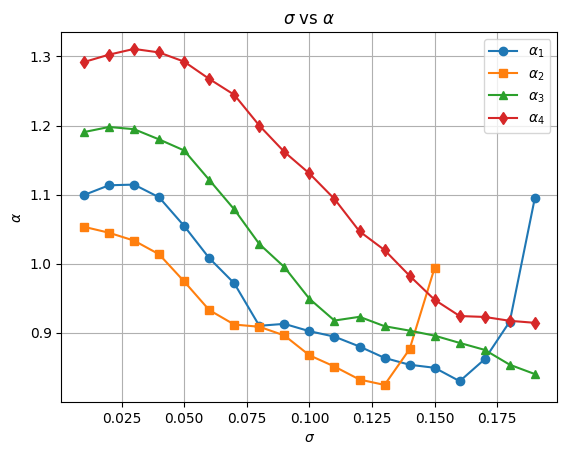

In [15]:
import matplotlib.pyplot as plt
import numpy as np

sigma = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.06, 0.07, 0.08, 0.09, 0.10,
    0.11, 0.12, 0.13, 0.14, 0.15,
    0.16, 0.17, 0.18, 0.19, 0.20
]

alpha_1 = [
    1.0994, 1.1135, 1.1145, 1.0961, 1.0546,
    1.0081, 0.9716, 0.9101, 0.9129, 0.9023,
    0.8944, 0.8801, 0.8636, 0.8537, 0.8493,
    0.8299, 0.8618, 0.9163, 1.0952, np.nan
]

alpha_2 = [
    1.0534, 1.0448, 1.0334, 1.0136, 0.9743,
    0.9329, 0.9119, 0.9087, 0.8961, 0.8674,
    0.8511, 0.8323, 0.8245, 0.8763, 0.9942,
    np.nan, np.nan, np.nan, np.nan, np.nan
]

alpha_3 = [
    1.1905, 1.1979, 1.1947, 1.1799, 1.1639,
    1.1214, 1.0786, 1.0285, 0.9951, 0.9492,
    0.9177, 0.9231, 0.9095, 0.9031, 0.8958,
    0.8853, 0.8752, 0.8537, 0.8402, np.nan
]

alpha_4 = [
    1.2919, 1.3026, 1.3109, 1.3058, 1.2925,
    1.2675, 1.2445, 1.2000, 1.1618, 1.1306,
    1.0937, 1.0468, 1.0197, 0.9825, 0.9477,
    0.9242, 0.9229, 0.9173, 0.9144, np.nan
]

plt.plot(sigma, alpha_1, marker='o', label=r'$\alpha_1$')
plt.plot(sigma, alpha_2, marker='s', label=r'$\alpha_2$')
plt.plot(sigma, alpha_3, marker='^', label=r'$\alpha_3$')
plt.plot(sigma, alpha_4, marker='d', label=r'$\alpha_4$')

plt.xlabel(r'$\sigma$')
plt.ylabel(r'$\alpha$')
plt.title(r'$\sigma$ vs $\alpha$')
plt.grid(True)
plt.legend()

plt.show()

In [11]:
def fix_sum_to_one(p):
    p = np.array(p, dtype=float)
    diff = 1.0 - p.sum()
    idx = np.argmax(p)
    p[idx] += diff
    return p


def trunc_error(sigma, low=-0.03, high=0.03, size=None):
    if sigma == 0:
        return np.zeros(size)
    a = low / sigma
    b = high / sigma
    return truncnorm.rvs(
        a,
        b,
        loc=0,
        scale=sigma,
        size=size
    )


def get_optimal_decoding_order(beta, h_val):
    beta = np.array(beta, dtype=float)
    h_val = np.array(h_val, dtype=float)
    return np.argsort(beta / h_val)


def cal_pow(R, DO, h_val):
    pow_vals = np.zeros(len(DO))
    for i in range(len(DO)):
        idx = DO[i]
        sum_i_M = np.sum([
            R[DO[k]]
            for k in range(i, len(DO))
        ])
        if i == len(DO) - 1:
            sum_ip1_M = 0
        else:
            sum_ip1_M = np.sum([
                R[DO[k]]
                for k in range(i + 1, len(DO))
            ])
        pow_vals[idx] = (
            2**(sum_i_M)
            -
            2**(sum_ip1_M)
        ) / h_val[idx]
    return pow_vals


def check_success_sic(hr, powers, rates, order):
    M = len(order)
    success = np.zeros(M, dtype=int)
    for j in range(M):
        user_j = order[j]
        signal = hr[user_j] * powers[user_j]
        interference = 0.0
        for k in range(j + 1, M):
            user_k = order[k]
            interference += (
                hr[user_k] * powers[user_k]
            )
        sinr = signal / (1 + interference)
        achievable_rate = np.log2(1 + sinr)
        # if achievable_rate >= rates[user_j]:
        #     success[user_j] = 1

        eps = 1e-10

        if achievable_rate + eps >= rates[user_j]:
            success[user_j] = 1
    return success

In [16]:
import numpy as np
from itertools import product
from multiprocessing import Pool, cpu_count
import time


SRP_age = []
sim_age = []

sigma_arr = np.arange(0.01, 0.1, 0.01)
for sigma in sigma_arr:
    n_user = 3
    h_bad = 0.1
    h_good = 1
    pr_h_bad = 0.5
    pr_h_good = 1.0 - pr_h_bad
    r_max = 2
    rho = np.arange(0, r_max + 1)
    P_bar_U = np.full(n_user, 2.0)
    alpha = 0.05
    max_iter = 50000
    pkt_prob = 0.9


    h_values_eff = [
    max(h_bad  - 0.75*sigma,  1e-6),
    max(h_good - 0.75*sigma, 1e-6)]

    h = np.array(
        list(product(h_values_eff, repeat=n_user)),
        dtype=np.float64)

    # print(h)
    num_h = len(h)
    prob_values = [pr_h_bad, pr_h_good]
    hp = np.array([np.prod(p) for p in product(prob_values, repeat=n_user)], dtype=np.float64)
    W = np.array(list(product(rho, repeat=n_user)), dtype=np.float64)
    num_W = len(W)
    psi = (W > 0).astype(np.float64)

    def cal_pow_all(W, beta, h_val):
        M = len(beta)
        order = np.argsort(beta / h_val)
        W_ordered = W[:, order]
        rev_cumsum = np.cumsum(W_ordered[:, ::-1], axis=1)[:, ::-1]
        P = np.zeros_like(W)
        for i in range(M):
            ui = order[i]
            sum_i_M = rev_cumsum[:, i]
            sum_ip1_M = 0 if i == M - 1 else rev_cumsum[:, i + 1]
            P[:, ui] = (2.0 ** sum_i_M - 2.0 ** sum_ip1_M) / h_val[ui]
        return P

    def process_channel_k(args):
        k, lambda_k, v_k = args
        h_k = h[k]
        Pk = cal_pow_all(W, lambda_k, h_k)

        costs = hp[k] * np.sum(
            pkt_prob * lambda_k * Pk
            - v_k * psi
            - lambda_k * P_bar_U * psi * (pkt_prob - 1),
            axis=1
        )

        min_cost = np.min(costs)
        idx = np.where(np.abs(costs - min_cost) < 1e-10)[0]
        mu = np.zeros(num_W)
        mu[idx] = 1.0 / len(idx)

        p_k  = hp[k] * np.sum(mu[:, None] * psi, axis=0)
        Pu_k = hp[k] * np.sum(mu[:, None] * Pk,  axis=0)

        return p_k, Pu_k, mu

    lambda_k = np.full(n_user, 0.1)
    v_k      = np.full(n_user, 0.1)

    acc_p   = np.zeros(n_user)
    acc_Pu  = np.zeros(n_user)
    acc_mu  = np.zeros((num_h, num_W))   # <-- accumulate mu per channel state
    acc_count = 0

    n_workers = cpu_count()
    # print(f"Using {n_workers} workers")
    t1 = time.time()

    with Pool(processes=n_workers) as pool:
        for itr in range(max_iter):
            args    = [(k, lambda_k.copy(), v_k.copy()) for k in range(num_h)]
            results = pool.map(process_channel_k, args)

            p   = np.zeros(n_user)
            P_u = np.zeros(n_user)

            for k, (p_k, Pu_k, mu) in enumerate(results):
                p   += p_k
                P_u += Pu_k
                if itr > 2:
                    acc_mu[k] += mu          # <-- accumulate ergodic mu

            if itr > 2:
                acc_p  += p
                acc_Pu += P_u
                acc_count += 1

            eta      = alpha / np.sqrt(itr + 1)
            lambda_k = np.maximum(0.0, lambda_k + eta * (
                pkt_prob * P_u - P_bar_U * (pkt_prob - pkt_prob * p + p)
            ))
            v_k = np.maximum(1e-10, v_k + eta * (1.0 / np.sqrt(v_k) - p))
    erg_mu = acc_mu / acc_count           # shape: (num_h, num_W)
    p_er    = acc_p / acc_count
    weights = np.ones(n_user) / n_user
    age_bar = np.sum(weights * pkt_prob * (1.0 / p_er - 1.0))
    # print("Final average age:", np.round(age_bar, 6))
    SRP_age.append(np.round(age_bar, 6))


    h_values = [h_bad, h_good]
    h = np.array(list(product(h_values, repeat=n_user)), dtype=np.float64)

    T = 100000
    M = n_user

    age = np.zeros(M)
    sum_age = np.zeros(M)
    fail_count = 0
    total_tx = 0
    sum_time = 0
    print('\n========================')
    print('sigma =', sigma)
    print('========================')
    for t in range(1, T + 1):
        t_start = time.time()
        pkts = np.random.choice(
            [1, 0],
            size=M,
            p=[pkt_prob, 1 - pkt_prob]        )
        h_val_test = np.random.choice(
            [h_bad, h_good],
            size=M,
            p=[0.5, 0.5]        )
        e = trunc_error(
            sigma=sigma,
            low=-0.05,
            high=0.05,
            size=M        )

        hr = h_val_test + e
        idx = np.where(
            np.all(
                np.isclose(h, h_val_test),
                axis=1
            )        )[0]

        if len(idx) == 0:
            continue
        idx_h = idx[0]
        age += pkts
        rho_idx = np.random.choice(
            np.arange(len(W)),
            size=1,
            p=fix_sum_to_one(erg_mu[idx_h])
        )
        idx_rho = rho_idx[0]
        best_bits = np.array(W[idx_rho])

        h_eff = np.maximum(
        h_val_test - 0.75*sigma,
        1e-6        )

        order = get_optimal_decoding_order(
            beta=lambda_k,
            h_val=h_eff        )

        powers = cal_pow(
            R=best_bits,
            DO=order,
            h_val=h_eff        )

        success = check_success_sic(
            hr=hr,
            powers=powers,
            rates=best_bits,
            order=order        )
        
        total_tx += np.sum(best_bits > 0)
        fail_count += np.sum(
            (best_bits > 0) & (success == 0)        )
        success_reset = (success > 0) & (best_bits > 0)
        age = age * np.where(success_reset, 0, 1)
        sum_age += age
        sum_time += (time.time() - t_start)

    avg_vaoi = np.mean(sum_age) / T
    fail_prob = fail_count / max(total_tx, 1)
    print(
        'Average VAoI =',
        np.round(avg_vaoi, 4)    )
    sim_age.append(np.round(avg_vaoi, 4) )
    print('------------------------------------------------')


sigma = 0.01
Average VAoI = 1.3192
------------------------------------------------

sigma = 0.02
Average VAoI = 1.3279
------------------------------------------------

sigma = 0.03
Average VAoI = 1.2812
------------------------------------------------

sigma = 0.04
Average VAoI = 1.2097
------------------------------------------------

sigma = 0.05
Average VAoI = 1.1152
------------------------------------------------

sigma = 0.060000000000000005
Average VAoI = 1.0243
------------------------------------------------

sigma = 0.06999999999999999
Average VAoI = 0.9566
------------------------------------------------

sigma = 0.08
Average VAoI = 0.9195
------------------------------------------------

sigma = 0.09
Average VAoI = 0.9202
------------------------------------------------


## Plot 1

In [ ]:
# age_w = []
# pow_arr = np.arange(1, 19, 1)
# for P_bar in pow_arr:
#     l = 0.5
#     D_bar = 0.05
#     res = SRP(P_bar, D_bar, l, 'w/ PA')
#     print('P_bar:', P_bar, 'opt age:', np.round(res, 4))
#     age_w.append(res)

In [ ]:
# age_wo_PA = []
# pow_arr = np.arange(1, 19, 1)
# for P_bar in pow_arr:
#     l = 0.5
#     D_bar = 0.05
#     res = SRP(P_bar, D_bar, l, 'wo PA')
#     print('P_bar:', P_bar, 'opt age:', np.round(res, 4))
#     age_wo_PA.append(res)

In [ ]:
# age_w_TDMA = []
# pow_arr = np.linspace(0.1, 1, 10)
# for P_bar in pow_arr:
#     l = 0.5
#     D_bar = 0.05
#     res = SRP(P_bar, D_bar, l)
#     print('P_bar:', P_bar, 'opt age:', np.round(res, 4))
#     age_w_TDMA.append(res)

In [ ]:
# plt.figure(figsize=(5, 3.5))
# plt.plot(pow_arr, age_w, '.-', label = 'VA-SRP w/ PA NOMA')
# plt.plot(pow_arr, age_wo_PA, '.-', label = 'VA-SRP w/o PA NOMA')
# # plt.plot(pow_arr, age_w_TDMA, '.-', label = 'VA-SRP w/ PA TDMA')
# plt.xlabel("P_bar")
# plt.ylabel("Average VAoI")
# plt.xlim(0, 19)
# plt.xticks(np.arange(0, 19, 1))
# plt.grid(True)
# plt.legend()
# plt.show()

## Plot 2

In [ ]:
# age_w_D = []
# d_arr = np.arange(0.005, 0.1, 0.005)
# for D_bar in d_arr:
#     P_bar = 2
#     l = 0.4
#     res = SRP(P_bar, D_bar, l, 'w/ PA')
#     print('D_bar:', D_bar, 'opt age:', np.round(res, 4))
#     age_w_D.append(res)

In [ ]:
# age_wo_D = []
# d_arr = np.arange(0.005, 0.1, 0.005)
# for D_bar in d_arr:
#     P_bar = 2
#     l = 0.4
#     res = SRP(P_bar, D_bar, l, 'w/o PA')
#     print('D_bar:', D_bar, 'opt age:', np.round(res, 4))
#     age_wo_D.append(res)

In [ ]:
# plt.figure(figsize=(5, 3.5))
# plt.plot(d_arr, age_w_D, '.-', label = 'VA-SRP w/ PA NOMA')
# plt.plot(d_arr, age_wo_D, '.-', label = 'VA-SRP wo PA NOMA')
# plt.xlabel("D_bar")
# plt.ylabel("Average VAoI")
# # plt.xlim(0, 19)
# # plt.xticks(np.arange(0, 19, 1))
# plt.grid(True)
# plt.legend()
# plt.show()

## Plot 3

In [ ]:
# age_wo_L = []
# lambda_arr = np.arange(0, 1.1, 0.1)
# for l in lambda_arr:
#     P_bar = 5
#     D_bar = 0.05
#     res = SRP(P_bar, D_bar, l, 'w/o PA')
#     print('lambda:', l, 'opt age:', np.round(res, 4))
#     age_wo_L.append(res)

In [ ]:
# age_w_L = []
# lambda_arr = np.arange(0, 1.1, 0.1)
# for l in lambda_arr:
#     P_bar = 5
#     D_bar = 0.05
#     res = SRP(P_bar, D_bar, l, 'w/ PA')
#     print('lambda:', l, 'opt age:', np.round(res, 4))
#     age_w_L.append(res)

In [ ]:
# plt.figure(figsize=(5, 3.5))
# plt.plot(lambda_arr, age_w_L, '.-', label = 'VA-SRP w/ PA NOMA')
# plt.plot(lambda_arr, age_wo_L, '.-', label = 'VA-SRP wo PA NOMA')
# plt.xlabel("lambda")
# plt.ylabel("Average VAoI")
# # plt.xlim(0, 19)
# # plt.xticks(np.arange(0, 19, 1))
# plt.grid(True)
# plt.legend()
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Parameters
# r_max = 2
# bit = np.linspace(0, r_max, 20)

# # Function
# y = (1 - bit / r_max)**2
# y2 = np.exp(-bit)

# # Plot
# plt.figure(figsize=(6, 4))
# plt.plot(bit, y, color='blue', linewidth=2, label=r'$(1 - \mathrm{bit}/r_{\max})^2$')
# plt.plot(bit, y2, color='red', linewidth=2, label=r'$\exp(-bit)$')
# plt.grid(True, which='both', linestyle='--', alpha=0.4)
# plt.xlabel('bit')
# plt.ylabel(r'$(1 - \mathrm{bit}/r_{\max})^2$')
# plt.title(r'Plot of $(1 - \mathrm{bit}/r_{\max})^2$ with $r_{\max}=2$')
# plt.legend()
# plt.show()


# Greedy

In [25]:

def feasible_D_rhos(bits, D):
    return all( int(b > 0)*(1 - b/2)**2 <= d for b, d in zip(bits, D))
def feasible_F_rhos(bits, h, P_avail):
    P = cp.Variable(3, nonneg=True)
    constraints = [P <= P_avail, P>= 0]
    for i in range(3):
        constraints.append(h[i] * P[i] >= 2**bits[i] - 1)
    for i in range(3):
        for j in range(i+1, 3):
            constraints.append(h[i]*P[i] + h[j]*P[j] >= 2**(bits[i] + bits[j]) - 1)
    constraints.append(sum(h[i]*P[i] for i in range(3)) >= 2**sum(bits) - 1)
    problem = cp.Problem(cp.Minimize(cp.sum(P)), constraints)
    problem.solve(solver=cp.SCS)
    return problem.value, P.value

pkt_prob = 0.5
n_user = 3
P_bar = 2
D_bar = 1
r_max = 2
rho = np.arange(0, r_max+1, 1)
W = list(product(rho, repeat=n_user))
################################################
P_consume = [0, 0, 0]
D_consume = [0, 0, 0]
age = np.array([0, 0, 0])
sum_age = np.array([0, 0, 0])
sum_time = 0
for t in range(1, 2001):
    h_vals = np.random.choice([1, 0.1], size=3, p=[0.5, 0.5])
    pkts =np.random.choice([1, 0], size=3, p=[pkt_prob, (1-pkt_prob)])

    t_start = time.time()
    Pow = [t * P_bar - P_consume[i] for i in range(3)]
    Dist = [t * D_bar - D_consume[i] for i in range(3)]

    age += pkts
    q_state = np.where(age > 0, 1, 0)
    feasible_list = []
    for rhos in W:
        bits = rhos * q_state
        if feasible_D_rhos(bits, Dist):
            res2, Ps = feasible_F_rhos(bits, h_vals, Pow)
            if np.isfinite(res2):
                feasible_list.append(bits)
    scores = [np.sum(age * np.where(x > 0, 0, 1)) for x in feasible_list]
    min_score = min(scores)
    best_bits_age = [x for x, s in zip(feasible_list, scores) if s == min_score]
    if best_bits_age:
        best_bits = max(best_bits_age, key=lambda x: np.sum(x))
    else:
        best_bits = np.array([0, 0, 0])
    age = age * np.where(best_bits > 0, 0, 1)
    _, used_pow = feasible_F_rhos(best_bits, h_vals, Pow)
    used_dist = np.array([int(b > 0)*(1 - b/2)**2 for b in best_bits])
    P_consume = P_consume + used_pow
    D_consume  = D_consume + used_dist
    sum_age+= age
    sum_time+= (time.time() - t_start)

    if t%100 == 0:
        print('lamdbda', pkt_prob, 't', t, 'Avg age:', np.round(np.mean(sum_age)/t, 4))
        print('compute time', np.round(sum_time/t, 5))
        print('--------------')

lamdbda 0.5 t 100 Avg age: 0.2833
compute time 0.18276
--------------
lamdbda 0.5 t 200 Avg age: 0.275
compute time 0.18075
--------------
lamdbda 0.5 t 300 Avg age: 0.2833
compute time 0.18118
--------------
lamdbda 0.5 t 400 Avg age: 0.285
compute time 0.1809
--------------
lamdbda 0.5 t 500 Avg age: 0.2833
compute time 0.18064
--------------


KeyboardInterrupt: 

# RR

In [ ]:
    def feasible_D_rhos(bits, D):
        return all( int(b > 0)*(1 - b/2)**2 <= d for b, d in zip(bits, D))
    def feasible_F_rhos(bits, h, P_avail):
        P = cp.Variable(3, nonneg=True)
        constraints = [P <= P_avail, P>= 0]
        for i in range(3):
            constraints.append(h[i] * P[i] >= 2**bits[i] - 1)
        for i in range(3):
            for j in range(i+1, 3):
                constraints.append(h[i]*P[i] + h[j]*P[j] >= 2**(bits[i] + bits[j]) - 1)
        constraints.append(sum(h[i]*P[i] for i in range(3)) >= 2**sum(bits) - 1)
        problem = cp.Problem(cp.Minimize(cp.sum(P)), constraints)
        problem.solve(solver=cp.SCS)
        return problem.value, P.value

In [ ]:
# lambda_arr = np.arange(0.05, 1.05, 0.1)
lambda_arr = [0.5]
for pkt_prob in lambda_arr:
    n_user = 3
    P_bar = 2
    D_bar = 0.06
    # pkt_prob = 0.5
    r_max = 2
    rho = np.arange(0, r_max+1, 1)
    W = [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (0, 2, 0), (0, 0, 1), (0, 0, 2) ]
    ################################################
    P_consume = [0, 0, 0]
    D_consume = [0, 0, 0]
    age = np.array([0, 0, 0])
    sum_age = np.array([0, 0, 0])
    users = [1, 2, 3]
    u = 0
    sum_time = 0
    for t in range(1, 2001):
        h_vals = np.random.choice([1, 0.1], size=3, p=[0.5, 0.5])
        pkts =np.random.choice([1, 0], size=3, p=[pkt_prob, (1-pkt_prob)])

        t_start = time.time()
        Pow = [t * P_bar - P_consume[i] for i in range(3)]
        Dist = [t * D_bar - D_consume[i] for i in range(3)]
        # print('h:', h_vals)
        # print('Available power:', np.round(Pow, 3))
        # print('Available Distortion:', np.round(Dist, 3))
        age += pkts
        q_state = np.where(age > 0, 1, 0)
        # one_hot = np.zeros(3, dtype=int)
        # one_hot[users[u] - 1] = 1
        # q_rr = q_state * one_hot
        # print('u', users[u])
        # print('queue state', q_state)
        # print('one hot',one_hot)
        # print('q rr', q_rr)
        # print('packets:', pkts)
        # print('age start:', age)
        # print('queue state', q_state)
        feasible_list = []
        for rhos in W:
            bits = rhos * q_state
            if feasible_D_rhos(bits, Dist):
                res2, Ps = feasible_F_rhos(bits, h_vals, Pow)
                if np.isfinite(res2):
                    feasible_list.append(bits)
        scores = [np.sum(age * np.where(x > 0, 0, 1)) for x in feasible_list]
        min_score = min(scores)
        best_bits_age = [x for x, s in zip(feasible_list, scores) if s == min_score]
        if best_bits_age:
            best_bits = max(best_bits_age, key=lambda x: np.sum(x))
        else:
            best_bits = np.array([0, 0, 0])
        age = age * np.where(best_bits > 0, 0, 1)
        _, used_pow = feasible_F_rhos(best_bits, h_vals, Pow)
        used_dist = np.array([int(b > 0)*(1 - b/2)**2 for b in best_bits])
        P_consume = P_consume + used_pow
        D_consume  = D_consume + used_dist
        sum_age+= age
        u = (u + 1) % len(users)
        # print('feasible_list', feasible_list)
        # print('best_bits_age', best_bits_age)
        # print(f"t={t}, chosen_bits={best_bits}")
        # print('consumed:', np.round(used_pow, 3), np.round(used_dist, 3))
        # print('age end', age)
        # print('Avg age:', np.mean(sum_age)/t)
        # print('------------------------------')
        sum_time+= (time.time() - t_start)
        if t%100 == 0:
            print('lamdbda', pkt_prob, 't', t, 'Avg age:', np.round(np.mean(sum_age)/t, 4))
            print('compute time', np.round(sum_time/t, 5))

In [1]:
import numpy as np
import cvxpy as cp
import time
from itertools import product

def feasible_F_rhos(bits, h, P_avail):
    M = len(bits)
    # Power variables
    P = cp.Variable(M, nonneg=True)
    constraints = [
        P >= 0,
        P <= P_avail    ]
    for mask in range(1, 2**M):
        subset_idx = [i for i in range(M) if (mask >> i) & 1]
        lhs = cp.sum([h[i] * P[i] for i in subset_idx])
        rhs = 2**(np.sum(bits[subset_idx])) - 1
        constraints.append(lhs >= rhs)
    # Objective: minimum total power
    problem = cp.Problem(cp.Minimize(cp.sum(P)), constraints)
    try:
        problem.solve(solver=cp.SCS, verbose=False)
        if P.value is None:
            return np.inf, np.zeros(M)
        return problem.value, np.maximum(P.value, 0)
    except:
        return np.inf, np.zeros(M)

# for M in range(5, 6, 1):
M = 4 
pkt_prob = 0.5              # number of users
P_bar = 2
r_max = 2
T = 2001
rho = np.arange(0, r_max + 1, 1)
W = np.array(list(product(rho, repeat=M)))
P_consume = np.zeros(M)
age = np.zeros(M, dtype=np.int64)
sum_age = np.zeros(M, dtype=np.int64)
sum_time = 0
for t in range(1, T + 1):
    h_vals = np.random.choice(
        [1.0, 0.1],
        size=M,
        p=[0.5, 0.5]    )
    pkts = np.random.choice(
        [1, 0],
        size=M,
        p=[pkt_prob, 1 - pkt_prob]    )
    t_start = time.time()
    Pow = np.array([
        t * P_bar - P_consume[i]
        for i in range(M)    ])
    age += pkts
    q_state = (age > 0).astype(int)
    feasible_list = []
    for rhos in W:
        bits = np.array(rhos) * q_state
        res2, Ps = feasible_F_rhos(bits, h_vals, Pow)
        if np.isfinite(res2):
            feasible_list.append(bits)
    if len(feasible_list) > 0:
        scores = [
            np.sum(age * np.where(x > 0, 0, 1))
            for x in feasible_list        ]
        min_score = min(scores)
        best_bits_age = [
            x for x, s in zip(feasible_list, scores)
            if s == min_score        ]
        best_bits = max(
            best_bits_age,
            key=lambda x: np.sum(x)        )
    else:
        best_bits = np.zeros(M)
    age = age * np.where(best_bits > 0, 0, 1)
    _, used_pow = feasible_F_rhos(
        best_bits,
        h_vals,
        Pow    )
    P_consume += used_pow
    sum_age += age
    sum_time += (time.time() - t_start)
    if t % 2 == 0:
        avg_age_per_user = sum_age / t
        print(
            f"M={M}, t={t}, "
            f"Avg age per user = {np.round(avg_age_per_user, 4)}, "
            f"Network Avg = {np.round(np.mean(avg_age_per_user), 4)}"        )

        print(
            "Average compute time per slot:",
            np.round(sum_time / t, 5)        )

print('------------------------')

M=5, t=2, Avg age per user = [0.  1.  0.5 0.  0. ], Network Avg = 0.3
Average compute time per slot: 0.81138
M=5, t=4, Avg age per user = [0.   0.5  0.25 0.5  0.25], Network Avg = 0.3
Average compute time per slot: 0.78754
M=5, t=6, Avg age per user = [0.     0.3333 0.1667 0.3333 0.1667], Network Avg = 0.2
Average compute time per slot: 0.78481
M=5, t=8, Avg age per user = [0.    0.25  0.125 0.25  0.125], Network Avg = 0.15
Average compute time per slot: 0.77931
M=5, t=10, Avg age per user = [0.1 0.2 0.1 0.2 0.1], Network Avg = 0.14
Average compute time per slot: 0.77878
M=5, t=12, Avg age per user = [0.0833 0.1667 0.0833 0.1667 0.0833], Network Avg = 0.1167
Average compute time per slot: 0.77666
M=5, t=14, Avg age per user = [0.0714 0.1429 0.0714 0.1429 0.0714], Network Avg = 0.1
Average compute time per slot: 0.77718
M=5, t=16, Avg age per user = [0.0625 0.1875 0.0625 0.125  0.0625], Network Avg = 0.1
Average compute time per slot: 0.77539
M=5, t=18, Avg age per user = [0.1667 0.1667

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7feb759a4ca0>>
Traceback (most recent call last):
  File "/home/sysad/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


M=5, t=364, Avg age per user = [0.294  0.1758 0.2775 0.2335 0.272 ], Network Avg = 0.2505
Average compute time per slot: 0.82171
M=5, t=366, Avg age per user = [0.2951 0.1749 0.276  0.235  0.2705], Network Avg = 0.2503
Average compute time per slot: 0.82152
M=5, t=368, Avg age per user = [0.2989 0.1739 0.2745 0.2337 0.269 ], Network Avg = 0.25
Average compute time per slot: 0.82128
M=5, t=370, Avg age per user = [0.3    0.173  0.2757 0.2324 0.2676], Network Avg = 0.2497
Average compute time per slot: 0.82105
M=5, t=372, Avg age per user = [0.3065 0.172  0.2742 0.2339 0.2661], Network Avg = 0.2505
Average compute time per slot: 0.82078
M=5, t=374, Avg age per user = [0.3102 0.1738 0.2754 0.2353 0.2647], Network Avg = 0.2519
Average compute time per slot: 0.82053
M=5, t=376, Avg age per user = [0.3085 0.1729 0.2739 0.2367 0.2633], Network Avg = 0.2511
Average compute time per slot: 0.82024


In [2]:
import numpy as np
import cvxpy as cp
import time
from itertools import product

# M = 4
for M in range(7,  11):
    pkt_prob = 0.5
    P_bar = 2
    r_max = 2
    T = 1001

    rho = np.arange(r_max + 1, dtype=np.int8)
    W = np.array(list(product(rho, repeat=M)), dtype=np.int8)

    SUBSETS = [
        np.array([i for i in range(M) if (mask >> i) & 1], dtype=np.int8)
        for mask in range(1, 2**M)
    ]

    P = cp.Variable(M, nonneg=True)

    bits_param = cp.Parameter(M, nonneg=True)
    rhs_param = cp.Parameter(len(SUBSETS), nonneg=True)

    h_param = cp.Parameter(M, nonneg=True)
    pow_param = cp.Parameter(M, nonneg=True)

    constraints = [
        P >= 0,
        P <= pow_param
    ]

    for k, subset_idx in enumerate(SUBSETS):

        lhs = cp.sum(
            cp.multiply(h_param[subset_idx], P[subset_idx])
        )

        constraints.append(lhs >= rhs_param[k])

    problem = cp.Problem(
        cp.Minimize(cp.sum(P)),
        constraints
    )

    def feasible_F_rhos(bits, h, P_avail):

        if np.any(bits > 0):

            req = (2 ** bits - 1) / np.maximum(h, 1e-12)

            if np.any(req > P_avail):
                return np.inf, None

        rhs_vals = np.array([
            2 ** np.sum(bits[idx]) - 1
            for idx in SUBSETS
        ])

        bits_param.value = bits
        rhs_param.value = rhs_vals
        h_param.value = h
        pow_param.value = P_avail

        try:

            problem.solve(
                solver=cp.SCS,
                warm_start=True,
                verbose=False
            )

            if P.value is None:
                return np.inf, None

            return problem.value, np.maximum(P.value, 0)

        except:
            return np.inf, None

    P_consume = np.zeros(M)

    age = np.zeros(M, dtype=np.int32)

    sum_age = np.zeros(M, dtype=np.float64)

    sum_time = 0

    for t in range(1, T + 1):

        t_start = time.time()

        h_vals = np.random.choice(
            [1.0, 0.1],
            size=M,
            p=[0.5, 0.5]
        )

        pkts = np.random.choice(
            [1, 0],
            size=M,
            p=[pkt_prob, 1 - pkt_prob]
        )

        Pow = t * P_bar - P_consume

        age += pkts

        q_state = (age > 0).astype(np.int8)

        feasible_list = []

        scores_list = []

        for rhos in W:

            bits = rhos * q_state

            if np.all(bits == 0):

                feasible_list.append(bits.copy())

                scores_list.append(np.sum(age))

                continue

            res2, _ = feasible_F_rhos(
                bits,
                h_vals,
                Pow
            )

            if np.isfinite(res2):

                feasible_list.append(bits.copy())

                score = np.sum(
                    age * (bits == 0)
                )

                scores_list.append(score)

        if len(feasible_list) > 0:

            scores_array = np.array(scores_list)

            min_score = np.min(scores_array)

            candidate_idx = np.where(
                scores_array == min_score
            )[0]

            candidate_actions = [
                feasible_list[i]
                for i in candidate_idx
            ]

            best_bits = max(
                candidate_actions,
                key=lambda x: np.sum(x)
            )

        else:

            best_bits = np.zeros(
                M,
                dtype=np.int8
            )

        age = age * (best_bits == 0)

        _, used_pow = feasible_F_rhos(
            best_bits,
            h_vals,
            Pow
        )

        if used_pow is not None:

            P_consume += used_pow

        sum_age += age

        sum_time += (
            time.time() - t_start
        )

        if t % 100 == 0:

            avg_age_per_user = sum_age / t

            print(
                f"M={M}, t={t}, "
                f"Avg age per user = "
                f"{np.round(avg_age_per_user, 4)}, "
                f"Network Avg = "
                f"{np.round(np.mean(avg_age_per_user), 4)}"
            )

            print(
                "Average compute time per slot:",
                np.round(sum_time / t, 5)
            )

    print('------------------------')

M=7, t=100, Avg age per user = [0.32 0.3  0.4  0.35 0.14 0.24 0.24], Network Avg = 0.2843
Average compute time per slot: 0.85156
M=7, t=200, Avg age per user = [0.38  0.23  0.355 0.445 0.26  0.32  0.23 ], Network Avg = 0.3171
Average compute time per slot: 0.83366
M=7, t=300, Avg age per user = [0.3333 0.2567 0.3633 0.4033 0.3367 0.34   0.34  ], Network Avg = 0.339
Average compute time per slot: 0.77937
M=7, t=400, Avg age per user = [0.36   0.26   0.3725 0.4225 0.305  0.3525 0.36  ], Network Avg = 0.3475
Average compute time per slot: 0.74951
M=7, t=500, Avg age per user = [0.342 0.288 0.362 0.426 0.324 0.372 0.386], Network Avg = 0.3571
Average compute time per slot: 0.71429
M=7, t=600, Avg age per user = [0.3617 0.2767 0.385  0.4383 0.335  0.3633 0.3667], Network Avg = 0.361
Average compute time per slot: 0.70272
M=7, t=700, Avg age per user = [0.35   0.2757 0.4014 0.42   0.3171 0.3757 0.3843], Network Avg = 0.3606
Average compute time per slot: 0.69821
M=7, t=800, Avg age per user 